# Arbol de Clasifiacion

Nelson Escalante - 22046

Este archivo incluye los incisos del 4 al 6 de la seccion de actividades.

### SETUP

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

train_path = "../data/train.csv"
train = pd.read_csv(train_path)

### INCISO 4:

Creacion del modelo de clasificacion

Definimos los limites de los precios de las casas en base a lo realizado en la entrega anterior.

In [2]:
p33 = train["SalePrice"].quantile(0.33)
p66 = train["SalePrice"].quantile(0.66)

print(f"Límite Económicas: Menos de ${p33:,.0f}")
print(f"Límite Intermedias: Entre ${p33:,.0f} y ${p66:,.0f}")
print(f"Límite Caras: Más de ${p66:,.0f}")

Límite Económicas: Menos de $139,000
Límite Intermedias: Entre $139,000 y $189,893
Límite Caras: Más de $189,893


Realizamos la division de los datos en el conjunto de prueba.

In [3]:
def categorize_price(price):
    if price <= p33:
        return "Económica"
    elif price <= p66:
        return "Intermedia"
    else:
        return "Cara"

# Aplicar la función a la columna SalePrice
train["PriceCategory"] = train["SalePrice"].apply(categorize_price)

# Verificar distribución de clases
train["PriceCategory"].value_counts()

PriceCategory
Cara          497
Económica     483
Intermedia    480
Name: count, dtype: int64

Generamos el arbol de clasificacion

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Seleccionar las variables predictoras (excluyendo SalePrice)
X = train.drop(columns=["SalePrice", "PriceCategory"])  
y = train["PriceCategory"]  # Variable objetivo

# Convertir variables categóricas en numéricas
X = pd.get_dummies(X, drop_first=True)

# Dividir en entrenamiento y prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")

# Crear el modelo de árbol de clasificación
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Conjunto de entrenamiento: (1022, 245)
Conjunto de prueba: (438, 245)


Ahora debemos verificar la eficiencia del algoritmo

<Figure size 800x600 with 0 Axes>

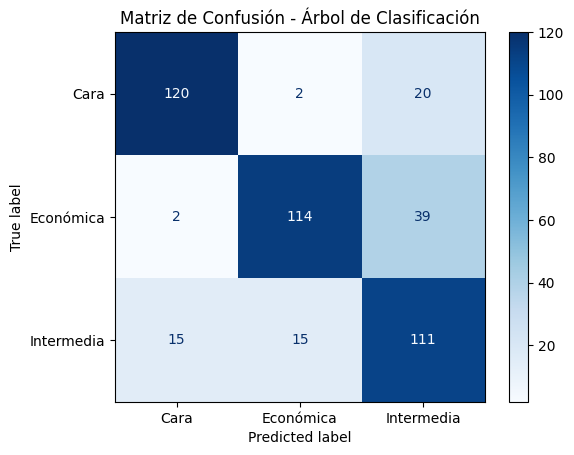

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Árbol de Clasificación")
plt.show()

In [6]:
aciertos = 120 + 114 + 111
total = 120 + 2 + 20 + 2 + 114 + 39 + 15 + 15 + 111
precision = aciertos / total
print(f"Precisión total: {precision:.4f}")

Precisión total: 0.7877


In [7]:
ac_int = 111
tot_int = 111 + 15 + 15
prec_int = ac_int / tot_int
print(f"Precision de casas intermedias: {prec_int:.4f}")

Precision de casas intermedias: 0.7872


El modelo cuenta con una precision total del 78.77%

Nuevamente, el modelo no tiene dificultades distinguiendo las casas caras de las economicas, lo cual es muy bueno ya que este tipo de errores es grave, y al tener pocos podemos asegurarnos de que el algoritmo no se confunde mucho entre ambos tipos. 

Las dificultades se muestran en la clasificacion con las casas intermedias. Al estar entre ambos tipos de casas, las confusiones son mucho mas comunes. Aun asi, la precision en las casas intermedias sigue siendo bastante alto, con un 78.72% de aciertos.

Toda esta informacion nos dice que el modelo es bastante confiable a la hora de predecir los precios de las casas.